In [21]:
import os, json, time, re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")
if OPENROUTER_API_KEY is None:
    raise ValueError("OPENROUTER_API_KEY is not set")

In [4]:
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY
)

In [5]:
df = pd.read_csv(r"F:\Thesis\project\403-vekalat\structured_questions.csv")
df.head(3)

,question_number,category,question,options
0,1,حقوق مدنی,کدام یک از موارد زیر صحیح است؟,1) با توافق طرفین امکان از بین بردن سبب انفساخ...
1,2,حقوق مدنی,شخص «الف» حین رانندگی با خودرو سواری با شخص «ب...,1) دیه هر دو راننده صرفاً تا میزان دیه کامل و ...
2,3,حقوق مدنی,کدام مورد در خصوص تصرفی که همراه با قصد تملک ب...,1) تصرف در مواردی مملک است حتی اگر همراه با قص...


In [22]:
def to_list(opts):
    if isinstance(opts, list): return opts
    if isinstance(opts, str):
        try:
            v = json.loads(opts)
            if isinstance(v, list): return v
        except Exception: pass
        for sep in ["|","؛",";","/","\\","،","\n"]:
            if sep in opts: return [x.strip() for x in opts.split(sep) if x.strip()]
        return [opts.strip()]
    return [str(opts)]

In [23]:
def render_numeric_options(opts):
    return "\n".join(f"{i+1}) {o}" for i, o in enumerate(opts))

In [24]:
def build_messages(question:str, options_text:str):
    return [
        {
            "role":"system",
            "content": (
                "You are a careful Persian legal reasoning assistant. "
                "First, think step by step in Persian (حداکثر 3 جمله) "
                "to justify ONLY the correct option based on Iranian law. "
                "Then output a JSON object ONLY with fields: "
                '{"explanation":"...","answer":"X","confidence":90}. '
                "⚠️ Do NOT mention other options. Output ONLY JSON."
            )
        },
        {
            "role":"user",
            "content": f"""سؤال:
{question}

گزینه‌ها:
{options_text}

Example output:
{{"explanation":"...","answer":"3","confidence":90}}"""
        }
    ]

In [25]:
def extract_json(content: str):
    """پاک‌سازی خروجی و استخراج اولین JSON معتبر"""
    if not content:
        return None
    try:
        # اگر کل متن خودش JSON باشه
        return json.loads(content)
    except:
        pass
    # جستجوی بلاک JSON با regex
    match = re.search(r"\{.*\}", content, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except:
            return None
    return None

In [26]:
def call_model(model:str, messages, temperature=0.7, max_tokens=512):
    t0 = time.time()
    try:
        resp = client.chat.completions.create(
            model=model,
            messages=messages,
            temperature=temperature,
            max_tokens=max_tokens
        )
        latency = int((time.time()-t0)*1000)
        content = resp.choices[0].message.content.strip()

        data = extract_json(content)
        if not data:
            raise ValueError("No valid JSON in response")

        return {
            "answer": str(data.get("answer","")).strip(),
            "confidence": int(data.get("confidence") or 0),
            "explanation": data.get("explanation",""),
            "raw": content,
            "latency_ms": latency,
            "error": None
        }
    except Exception as e:
        latency = int((time.time()-t0)*1000)
        return {
            "answer": None,
            "confidence": None,
            "explanation": None,
            "raw": str(e),
            "latency_ms": latency,
            "error": str(e)
        }

In [27]:
def majority_vote(runs):
    votes = Counter([r["answer"] for r in runs if r["answer"] and r["answer"].isdigit()])
    if not votes:
        return None, 0.0, 0.0
    winner, count = votes.most_common(1)[0]
    confs = [r["confidence"] for r in runs if r["answer"] == winner and r["confidence"] is not None]
    conf_mean = round(sum(confs)/len(confs), 1) if confs else 0.0
    conf_vote = round(count / len(runs), 2)
    return winner, conf_mean, conf_vote

In [28]:
def run_self_consistency_parallel(model, df, k=5, temps=[0.6,0.7,0.8,0.6,0.75], limit=None):
    rows = []
    for idx, row in df.iterrows():
        if limit and idx >= limit:
            break
        qid = row.get("id", idx)
        q = row["question"]
        opts_list = to_list(row["options"])
        options_text = render_numeric_options(opts_list)
        messages = build_messages(q, options_text)

        runs = []
        with ThreadPoolExecutor(max_workers=min(k, 5)) as executor:
            futures = [
                executor.submit(call_model, model, messages, temps[i % len(temps)], 512)
                for i in range(k)
            ]
            for future in as_completed(futures):
                runs.append(future.result())

        winner, conf_mean, conf_vote = majority_vote(runs)
        votes_count = Counter([r["answer"] for r in runs if r["answer"]])

        rec = {
            "id": qid,
            "model": model,
            "answer_final": winner,
            "confidence_mean": conf_mean,
            "confidence_vote": conf_vote,
            "votes_map": json.dumps(dict(votes_count), ensure_ascii=False),
            "latency_avg_ms": round(sum([r["latency_ms"] for r in runs])/len(runs), 1),
        }
        for i, r in enumerate(runs[:k], start=1):
            rec[f"answer_run{i}"] = r["answer"]
            rec[f"confidence_run{i}"] = r["confidence"]
            rec[f"explanation_run{i}"] = r["explanation"]
            rec[f"error_run{i}"] = r.get("error")
        rows.append(rec)

    return pd.DataFrame(rows)

In [32]:
print("⏳ Running self-consistency for Gemini 2.5 Flash...")
results = run_self_consistency_parallel("google/gemini-2.5-flash", df, k=5, limit=None)
print(results)

⏳ Running self-consistency for Gemini 2.5 Flash...
      id                    model answer_final  confidence_mean  \
0      0  google/gemini-2.5-flash            3             90.0   
1      1  google/gemini-2.5-flash            2             90.0   
2      2  google/gemini-2.5-flash            4             90.0   
3      3  google/gemini-2.5-flash            4             90.0   
4      4  google/gemini-2.5-flash            3             90.0   
..   ...                      ...          ...              ...   
115  115  google/gemini-2.5-flash            3             90.0   
116  116  google/gemini-2.5-flash            2             90.0   
117  117  google/gemini-2.5-flash            3             90.0   
118  118  google/gemini-2.5-flash            1             90.0   
119  119  google/gemini-2.5-flash            4             90.0   

     confidence_vote                 votes_map  latency_avg_ms answer_run1  \
0                1.0                  {"3": 5}          2363.4    

In [35]:
with pd.ExcelWriter("results_sc_gemini_flash.xlsx", engine="openpyxl") as writer:
    summary = results[["id","model","answer_final","confidence_mean","confidence_vote","votes_map","latency_avg_ms"]]
    summary.to_excel(writer, sheet_name="Summary", index=False)
    results.to_excel(writer, sheet_name="Details", index=False)

print("✅ Saved to results_sc_gemini_flash.xlsx")
print(results.head())

✅ Saved to results_sc_gemini_flash.xlsx
   id                    model answer_final  confidence_mean  confidence_vote  \
0   0  google/gemini-2.5-flash            3             90.0              1.0   
1   1  google/gemini-2.5-flash            2             90.0              1.0   
2   2  google/gemini-2.5-flash            4             90.0              1.0   
3   3  google/gemini-2.5-flash            4             90.0              0.8   
4   4  google/gemini-2.5-flash            3             90.0              1.0   

          votes_map  latency_avg_ms answer_run1  confidence_run1  \
0          {"3": 5}          2363.4           3             90.0   
1          {"2": 5}          1920.0           2             90.0   
2          {"4": 5}          1544.8           4             90.0   
3  {"4": 4, "2": 1}          1730.0           4             90.0   
4          {"3": 5}          1293.6           3             90.0   

                                    explanation_run1  ...  \
0  

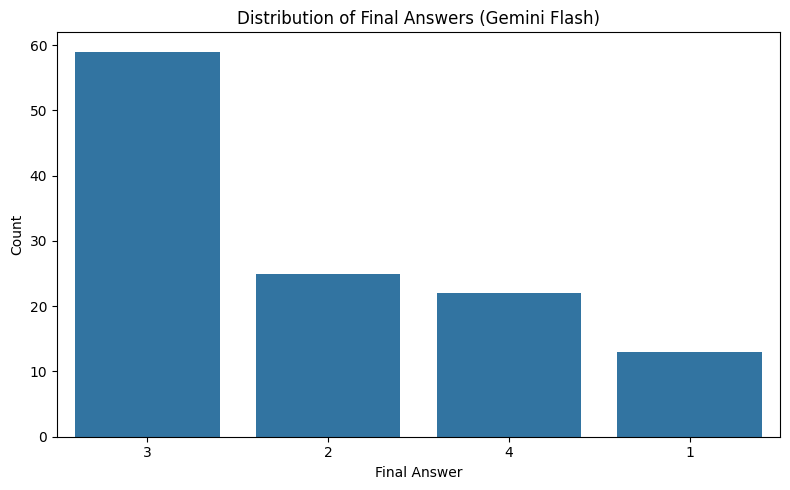

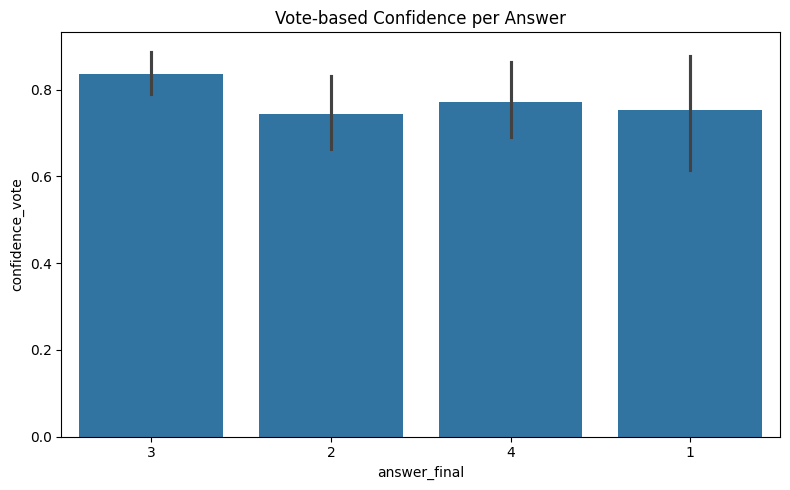

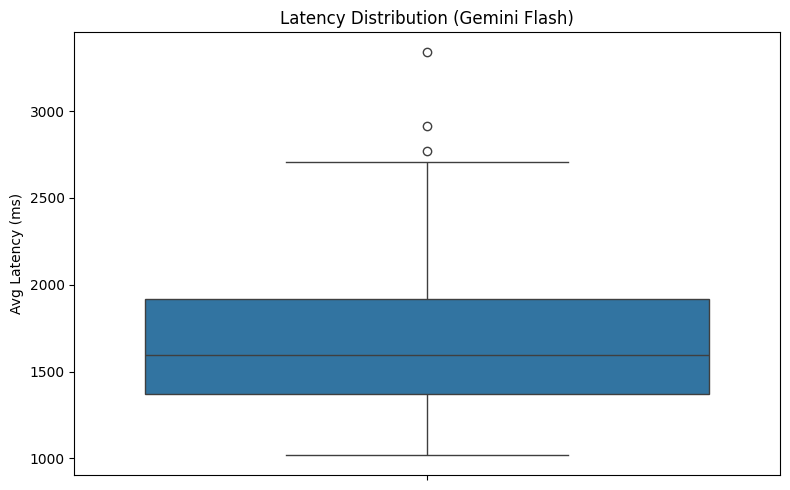


📊 Summary Statistics:
confidence_mean      89.250000
confidence_vote       0.790000
latency_avg_ms     1690.021667
dtype: float64


In [34]:
# --- تحلیل آماری ساده ---
plt.figure(figsize=(8,5))
sns.countplot(data=results, x="answer_final")
plt.title("Distribution of Final Answers (Gemini Flash)")
plt.xlabel("Final Answer")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=results, x="answer_final", y="confidence_vote")
plt.title("Vote-based Confidence per Answer")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=results, y="latency_avg_ms")
plt.title("Latency Distribution (Gemini Flash)")
plt.ylabel("Avg Latency (ms)")
plt.tight_layout()
plt.show()

print("\n📊 Summary Statistics:")
summary_stats = results[["confidence_mean","confidence_vote","latency_avg_ms"]].mean()
print(summary_stats)